<a href="https://colab.research.google.com/github/DrNeethuSRavi/Computer-Vision-Using-Python/blob/main/CVusingPython_Chapter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [ ]:
# Variables and data types

width=640
height=480
channels=3

x=10
y=3.14
name="Computer Vision"
flag=True

print(type(x))
print(type(y))
print(type(name))
print(type(flag))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


In [ ]:
# Python List Vs NumPy Arrays

pixels_list=[10,20,30]
print(pixels_list*2)

pixel_array=np.array([10,20,30])
print(pixel_array*2)

[10, 20, 30, 10, 20, 30]
[20 40 60]


In [ ]:
# NumPy Arrays as Images

image=np.array([
    [0,50,100],
    [150,200,250],
    [30,80,120]
])

print(image)
print(image.shape)
print(image.ndim)
print(image.dtype)

[[  0  50 100]
 [150 200 250]
 [ 30  80 120]]
(3, 3)
2
int64


In [ ]:
# Image Coordinate Systens and Indexing

pixel=image[1,2]
print(pixel)

250


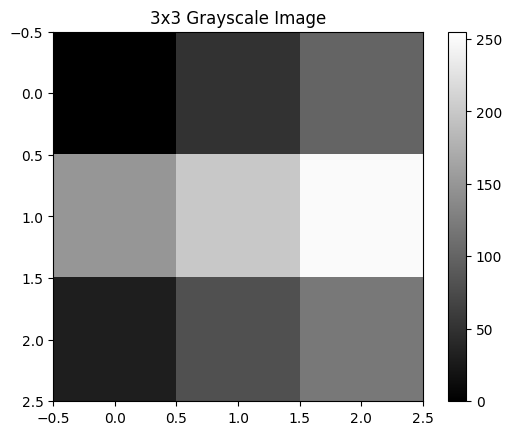

In [ ]:
# Visualizing an Image with Matplotlib

plt.imshow(image,cmap="gray",vmin=0,vmax=255)
plt.colorbar()
plt.title("3x3 Grayscale Image")
plt.show()


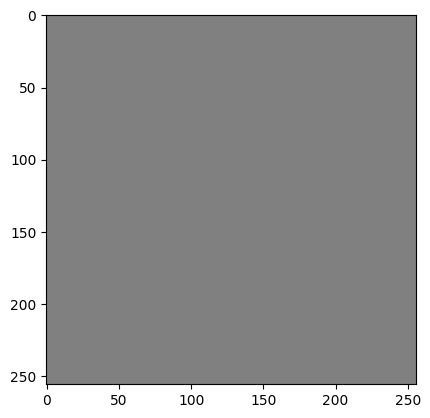

In [ ]:
# Creating Synthetic Image

# Black, white and gray images

black_image=np.zeros((256,256),dtype=np.uint8)
white_image=np.ones((256,256),dtype=np.uint8)*255
gray_image=np.ones((256,256),dtype=np.uint8)*128

plt.imshow(gray_image, cmap="gray",vmin=0,vmax=255)
plt.show()


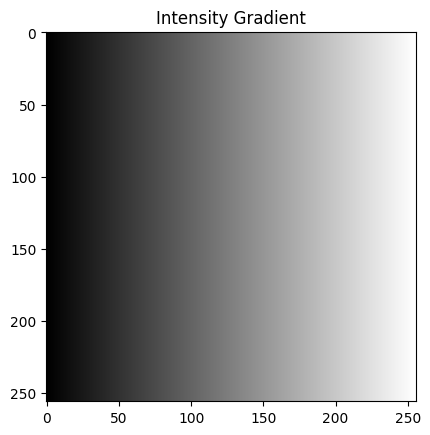

In [ ]:
# Intensity gradient

gradient_row=np.linspace(0,255,256)
gradient=np.tile(gradient_row,(256,1))

plt.imshow(gradient,cmap="gray", vmin=0, vmax=255)
plt.title("Intensity Gradient")
plt.show()

In [ ]:
# Bit Depth, Dynamic Range and Data Type

print(gray_image.dtype)
print(np.iinfo(np.uint8))
print(np.iinfo(np.uint16))


# Overflow Caution

a=np.array([250],dtype=np.uint8)
print(a + 10)

uint8
Machine parameters for uint8
---------------------------------------------------------------
min = 0
max = 255
---------------------------------------------------------------

Machine parameters for uint16
---------------------------------------------------------------
min = 0
max = 65535
---------------------------------------------------------------

[4]


In [ ]:
# Reading Real Images with OpenCV

from google.colab import files

uploaded = files.upload()

img_bgr=cv2.imread("flower.jpg")

if img_bgr is None:
  print("Image could not be loaded")
else:
  print("Shape:",img_bgr.shape)
  print("Data type:", img_bgr.dtype)
  print("Minimum:", img_bgr.min())
  print("Maximum:", img_bgr.max())


Saving flower.jpg to flower (1).jpg
Shape: (480, 640, 3)
Data type: uint8
Minimum: 41
Maximum: 255


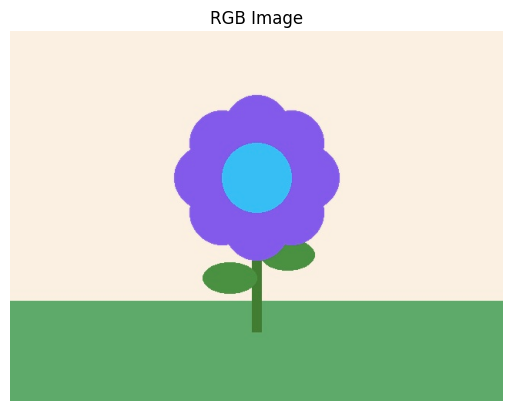

In [ ]:
# BGR vs RGB

img_rgb=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)

plt.imshow(img_bgr)
plt.title("RGB Image")
plt.axis("off")
plt.show()

In [ ]:
# Image Dimensions and Pixel Access

height,width,channels = img_rgb.shape
print("Height:",height)
print("Width:",width)
print("Channels:",channels)

pixel = img_rgb[100,200]
R,G,B = pixel

print("R:",R,"G:",G,"B:",B)

Height: 480
Width: 640
Channels: 3
R: 226 G: 240 B: 251


(480, 640) (480, 640) (480, 640)


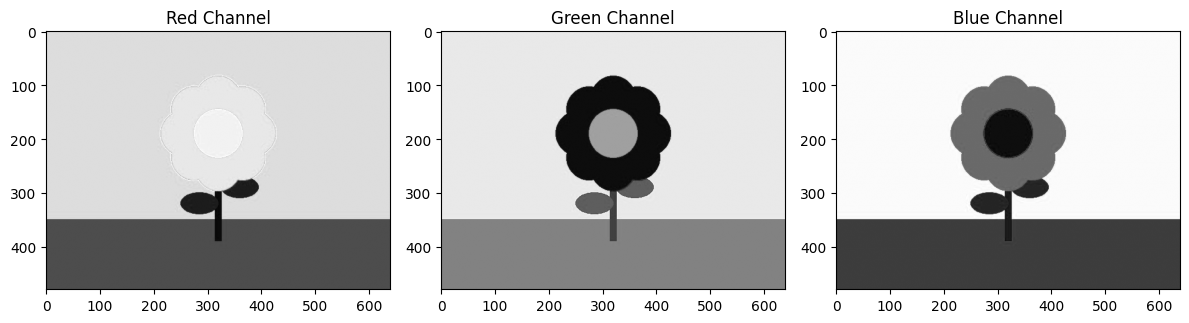

In [ ]:
# Channel Seperation

R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

print(R.shape, G.shape, B.shape)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")

plt.tight_layout()
plt.show()

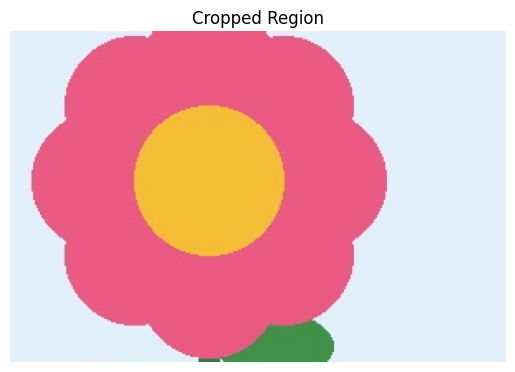

In [ ]:
# NumPy Slicing, Cropping, and Region of Tnterest

crop=img_rgb[100:300, 200:500]

plt.imshow(crop)
plt.title("Cropped Region")
plt.axis("off")
plt.show()

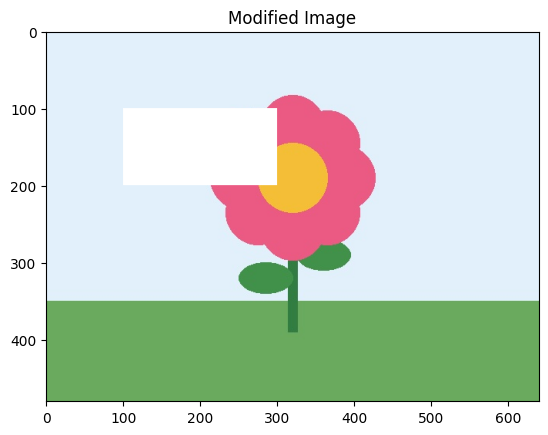

In [ ]:
# Modifying Pixels and Image Copies

modified = img_rgb.copy()
modified[100:200,100:300]=255

plt.imshow(modified)
plt.title("Modified Image")
plt.show()


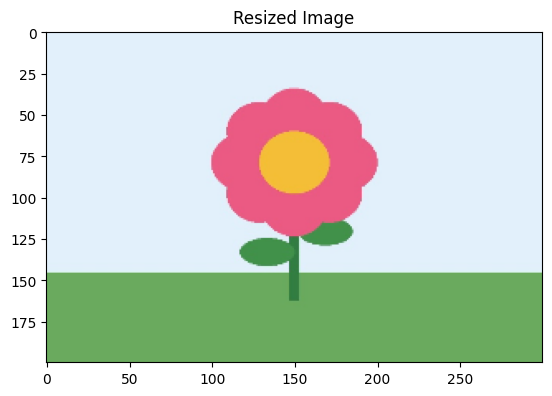

In [ ]:
# Resizing

resized =cv2.resize(img_rgb,(300,200))

plt.imshow(resized)
plt.title("Resized Image")
plt.show()

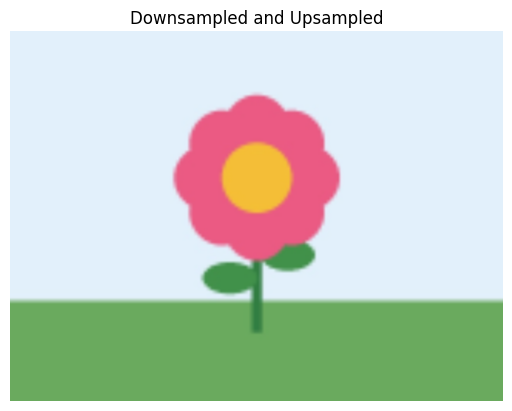

In [ ]:
# Sampling: From Continuous Scenes to Discrete Pixels

# Down Sampling and Up Sampling

h, w= img_rgb.shape[:2]

small = cv2.resize(img_rgb, (w // 4, h // 4 ), interpolation=cv2.INTER_AREA)

restored=cv2.resize(small,(w, h), interpolation=cv2.INTER_LINEAR)

plt.imshow(restored)
plt.title("Downsampled and Upsampled")
plt.axis("off")
plt.show()


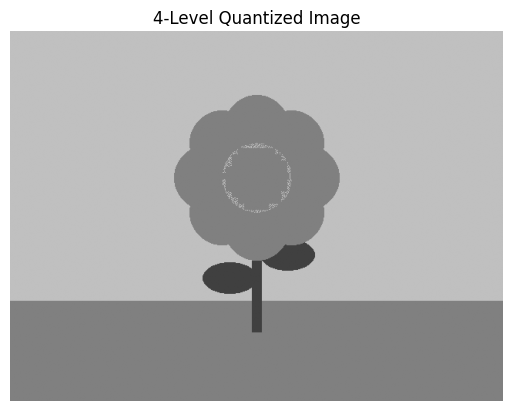

In [ ]:
# Quantization

gray = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2GRAY)

levels = 4
step = 256 / levels

quantized = np.floor(gray.astype(np.float32)/step)*step
quatized = np.clip(quantized,0,255).astype(np.uint8)

plt.imshow(quantized, cmap="gray", vmin=0, vmax=255)
plt.title("4-Level Quantized Image")
plt.axis("off")
plt.show()


In [ ]:
# Normalization and Floating Point Image Representation

img_float=img_rgb.astype(np.float32) / 255.0

print(img_float.dtype)
print(img_float.min())
print(img_float.max())

img_uint8 = np.clip(img_float*255.0,0,255).astype(np.uint8)

float32
0.16078432
1.0


In [ ]:
# Basic Image Statistics

gray= cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

print("Maximum:", gray.max())
print("Minimum:", gray.min())
print("Mean:", gray.mean())
print("Standard deviation:", gray.std())


Maximum: 243
Minimum: 90
Mean: 199.81595052083333
Standard deviation: 46.96177488413726


In [ ]:
# Saving Results

output_bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
cv2.imwrite("Output_image.png",output_bgr)

True